In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime as dt
from datetime import time
from datetime import timedelta

['2025-06-17T09:00:00.000000000' '2025-06-17T09:30:00.000000000'
 '2025-06-17T10:00:00.000000000' '2025-06-17T10:30:00.000000000'
 '2025-06-17T11:00:00.000000000' '2025-06-17T11:30:00.000000000'
 '2025-06-17T12:00:00.000000000' '2025-06-17T12:30:00.000000000'
 '2025-06-20T09:00:00.000000000' '2025-06-20T09:30:00.000000000'
 '2025-06-20T10:00:00.000000000' '2025-06-20T10:30:00.000000000'
 '2025-06-20T11:00:00.000000000' '2025-06-20T11:30:00.000000000'
 '2025-06-20T12:00:00.000000000' '2025-06-20T12:30:00.000000000'
 '2025-06-20T13:00:00.000000000' '2025-06-23T12:30:00.000000000'
 '2025-06-23T13:30:00.000000000' '2025-06-24T09:00:00.000000000'
 '2025-06-24T09:30:00.000000000' '2025-06-24T13:00:00.000000000'
 '2025-06-24T13:30:00.000000000' '2025-06-24T14:00:00.000000000'
 '2025-06-25T11:30:00.000000000' '2025-06-25T12:30:00.000000000'
 '2025-06-25T13:00:00.000000000' '2025-06-25T14:00:00.000000000'
 '2025-06-25T14:30:00.000000000' '2025-06-26T09:00:00.000000000'
 '2025-06-26T09:30:00.000

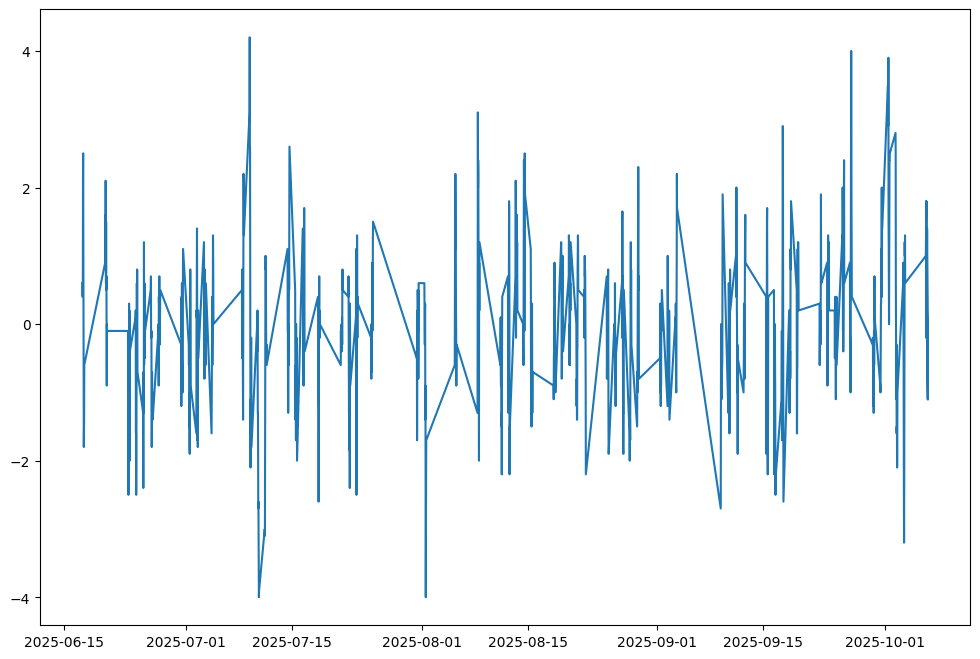

In [28]:
# def auswertung(csv_datei : str, stunden : timedelta, start : dt) -> np.ndarray:
#     df = pd.read_csv('ALV_intraday.csv')
#     df['Datum'] = pd.to_datetime(df['Datum'])
#     df['Uhrzeit'] = pd.to_timedelta(df['Uhrzeit'])
#     df['Timestamp'] = df['Datum'] + df['Uhrzeit']
#     # print(df.head())
#     Zeit = df['Timestamp'] #.to_numpy()
#     Kurs = df['Kurs_EUR'] #.to_numpy()
    
#     diff_array = []
#     for i in range(len(Zeit)):
#         Zeit_in = Zeit.iloc[i]
#         Zeit_out = Zeit.iloc[i] + stunden
#         if Zeit_out in Zeit:
#             diff_array.append(Kurs[Zeit.loc[Zeit_out].index]-Kurs[i])

#     return diff_array

# auswertung('ALV_intraday.csv', 2)

import pandas as pd
import numpy as np
from datetime import timedelta

def auswertung(csv_datei: str, stunden: int) -> np.ndarray:
    # CSV einlesen
    df = pd.read_csv(csv_datei)
    df['Datum'] = pd.to_datetime(df['Datum'])
    df['Uhrzeit'] = pd.to_timedelta(df['Uhrzeit'])
    df['Timestamp'] = df['Datum'] + df['Uhrzeit']
    
    # Kurs- und Zeitspalten
    Zeit = df['Timestamp']
    Kurs = df['Kurs_EUR']
    
    # DataFrame für Join vorbereiten
    df_shift = df.copy()
    df_shift['Timestamp'] = df_shift['Timestamp'] - timedelta(hours=stunden)
    
    # Merge: jeder Timestamp bekommt den Kurs von "stunden" später
    merged = pd.merge(df, df_shift[['Timestamp', 'Kurs_EUR']], on='Timestamp', suffixes=('', '_später'))
    Zeit2 = merged['Timestamp']
    Zeit2.dropna(inplace=True)
    Zeit2 = Zeit2.to_numpy()
    
    # Differenz berechnen
    diff_array = (merged['Kurs_EUR_später'] - merged['Kurs_EUR'])
    diff_array.dropna(inplace=True)
    diff_array = diff_array.to_numpy()

    return diff_array, Zeit2

# Beispielaufruf:
differenzen, Zeit2 = auswertung('ALV_intraday.csv', 2)
# print(differenzen)
diff_pos_index = np.where(differenzen > 0)
diff_pos = Zeit2[diff_pos_index]
# diff_neg = Zeit2.where(differenzen < 0, np.nan)

plt.figure(figsize=(12, 8))
plt.plot(Zeit2, differenzen)

print(diff_pos)




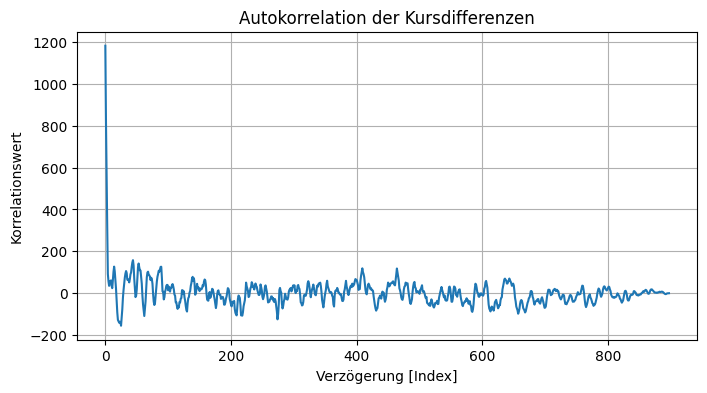

np.int64(1)

In [20]:
def rhythmus_autokorrelation(diff_array: np.ndarray, plot: bool = True):
    """
    Analysiert zeitliche Wiederholungen (Rhythmen) per Autokorrelation.
    """
    diff_array = diff_array - np.mean(diff_array)
    autocorr = np.correlate(diff_array, diff_array, mode='full')
    autocorr = autocorr[autocorr.size // 2:]  # Nur positive Verzögerungen
    
    if plot:
        plt.figure(figsize=(8,4))
        plt.plot(autocorr)
        plt.title("Autokorrelation der Kursdifferenzen")
        plt.xlabel("Verzögerung [Index]")
        plt.ylabel("Korrelationswert")
        plt.grid(True)
        plt.show()
    
    # Position des größten Nebenmaximums:
    idx_max = np.argmax(autocorr[1:]) + 1
    return idx_max

rhythmus_autokorrelation(diff_array=differenzen)


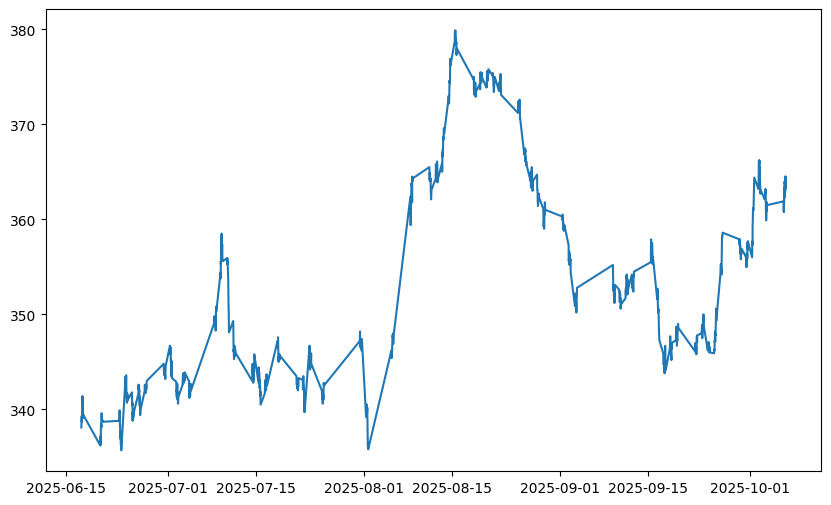

In [8]:
df = pd.read_csv('ALV_intraday.csv')
df['Datum'] = pd.to_datetime(df['Datum'])
df['Uhrzeit'] = pd.to_timedelta(df['Uhrzeit'])
df['Timestamp'] = df['Datum'] + df['Uhrzeit']
# print(df.head())
Zeit = df['Timestamp'].to_numpy()
Kurs = df['Kurs_EUR'].to_numpy()

plt.figure(figsize=(10, 6))
plt.plot(Zeit, Kurs)

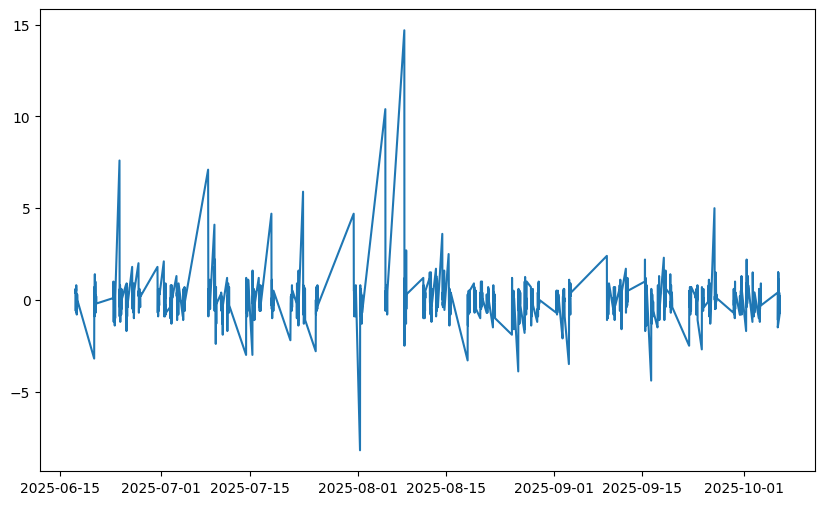

In [9]:
diff_array = df['Kurs_EUR'].diff()

plt.figure(figsize=(10, 6))
plt.plot(Zeit, diff_array)

In [10]:
import numpy as np
import datetime

# --- Beispieldaten (ersetze diese durch deine echten Daten) ---
# Erstellen wir eine plausible Zeitreihe für die Demonstration
# zeit_start = datetime.datetime(2024, 1, 1)
# anzahl_tage = 200
# Zeit-Array mit täglichen Daten
zeit = Zeit

# Kurs-Array: Eine Mischung aus stabilem Wachstum und volatilen Phasen
kurs = Kurs

# diff_array: Die Differenz zwischen aufeinanderfolgenden Kurswerten
diff_array = np.diff(kurs)
# Wir brauchen für die Analyse den Kurs und die Differenzen ab dem zweiten Tag
kurs_analyse = kurs[1:]
zeit_analyse = zeit[1:]

# --- Analyse-Parameter (diese kannst du anpassen) ---

# Größe des Zeitfensters in Tagen
fenster_groesse = 30
# Mindestwachstum in Prozent, das in diesem Fenster erreicht werden muss
wachstums_schwelle = 2
# Maximale Anzahl an Tagen, an denen der Kurs fallen darf
max_rueckgaenge = 10

# --- Analyse mit dem gleitenden Fenster ---

gefundene_intervalle = []

# Wir durchlaufen die Daten mit dem Fenster
# Der Loop stoppt, sodass das Fenster nicht über das Ende der Daten hinausragt
for i in range(len(diff_array) - fenster_groesse + 1):
    # Aktuelles Fenster aus den Daten extrahieren
    start_index = i
    end_index = i + fenster_groesse

    fenster_diff = diff_array[start_index:end_index]
    kurs_start = kurs_analyse[start_index]
    kurs_ende = kurs_analyse[end_index - 1]

    # 1. Kriterium: Wachstum berechnen
    gesamtwachstum = ((kurs_ende - kurs_start) / kurs_start) * 100

    # 2. Kriterium: Anzahl der Rückgänge zählen
    anzahl_rueckgaenge = np.sum(fenster_diff < 0)

    # Prüfen, ob beide Kriterien erfüllt sind
    if gesamtwachstum >= wachstums_schwelle and anzahl_rueckgaenge <= max_rueckgaenge:
        # Wenn ja, speichere das Start- und Enddatum des Intervalls
        intervall_start = zeit_analyse[start_index]
        intervall_ende = zeit_analyse[end_index - 1]
        gefundene_intervalle.append({
            "start": intervall_start,
            "ende": intervall_ende,
            "wachstum": gesamtwachstum,
            "rueckgaenge": anzahl_rueckgaenge
        })

# --- Ergebnisse ausgeben ---
if gefundene_intervalle:
    print(f"Es wurden {len(gefundene_intervalle)} passende Intervalle gefunden:\n")
    for intervall in gefundene_intervalle:
        print(f"Intervall: {intervall['start'].strftime('%Y-%m-%d')} bis {intervall['ende'].strftime('%Y-%m-%d')}")
        print(f"  -> Wachstum: {intervall['wachstum']:.2f}%")
        print(f"  -> Tage mit Kursrückgang: {intervall['rueckgaenge']} von {fenster_groesse} Tagen\n")
else:
    print("Keine Intervalle gefunden, die den Kriterien entsprechen.")
    print("Tipp: Versuche, die `wachstums_schwelle` zu senken oder `max_rueckgaenge` zu erhöhen.")

Es wurden 29 passende Intervalle gefunden:



AttributeError: 'numpy.datetime64' object has no attribute 'strftime'